AUC results saved to: D:\Topologicalcancer-signatures\Breast_gene_AUC_results.xlsx
ROC plot saved to: D:\Topologicalcancer-signatures\Breast_gene_AUC.png


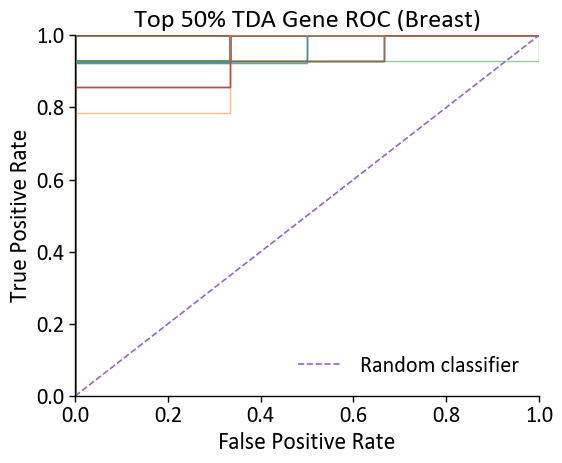

Plotted 94 genes.


In [1]:
# AUC Calculations 
# Input: Integrated gene profiles of the healthy and cancer samples (Example: Breast-GeneProfiles.xlsx)

# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve


def compute_auc_and_plot(
    file_path,
    cancer_type="Cancer",
    healthy_cols=None,
    cancer_cols=None,
    auc_output_path=None,
    roc_output_path=None,
    top_fraction=0.5
):
    """
    Compute gene-wise AUC and plot ROC curves for top genes.

    Parameters:
    ----------
    file_path : str
        Path to input Excel file
    cancer_type : str
        Name of cancer (used in plot title & filenames)
    healthy_cols : list
        Column names for healthy samples
    cancer_cols : list
        Column names for cancer samples
    auc_output_path : str
        Path to save AUC results Excel
    roc_output_path : str
        Path to save ROC plot image
    top_fraction : float
        Fraction of top genes to plot (default = 0.5)
    """

    # -----------------------------
    # Load data
    # -----------------------------
    df = pd.read_excel(file_path)

    # Convert numeric columns
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Default sample columns if not provided
    if healthy_cols is None:
        healthy_cols = ["Sample_1", "Sample_2", "Sample_3"]

    if cancer_cols is None:
        cancer_cols = [f"Sample_{i}" for i in range(4, 18)]

    labels = np.array([0]*len(healthy_cols) + [1]*len(cancer_cols))

    results = []

    # -----------------------------
    # AUC Calculation
    # -----------------------------
    for _, row in df.iterrows():

        gene = row["Gene"]

        healthy_vals = row[healthy_cols].astype(float).values
        cancer_vals = row[cancer_cols].astype(float).values

        values = np.concatenate([healthy_vals, cancer_vals]).astype(float)

        mask = ~pd.isna(values)

        values = values[mask]
        y = labels[mask]

        if len(np.unique(y)) < 2:
            continue

        auc = roc_auc_score(y, values)

        results.append([gene, auc])

    # Create DataFrame
    auc_df = pd.DataFrame(results, columns=["Gene", "AUC"])
    auc_df = auc_df.sort_values("AUC", ascending=False)

    # Save AUC results
    if auc_output_path:
        auc_df.to_excel(auc_output_path, index=False)
        print(f"AUC results saved to: {auc_output_path}")

    # -----------------------------
    # ROC Plot for Top Genes
    # -----------------------------
    top_n = max(1, int(len(auc_df) * top_fraction))
    top_genes = auc_df.head(top_n)["Gene"].values

    # Style
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Calibri"],
        "font.size": 19,
        "axes.labelsize": 17,
        "axes.titlesize": 19,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    })

    plt.figure(figsize=(6, 5))

    for gene in top_genes:

        row = df[df["Gene"] == gene].iloc[0]

        healthy_vals = row[healthy_cols].astype(float).values
        cancer_vals = row[cancer_cols].astype(float).values

        values = np.concatenate([healthy_vals, cancer_vals]).astype(float)

        mask = ~pd.isna(values)
        values = values[mask]
        y = labels[mask]

        fpr, tpr, _ = roc_curve(y, values)

        plt.plot(fpr, tpr, linewidth=1, alpha=0.5)

    # Random classifier
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, label="Random classifier")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Top {int(top_fraction*100)}% TDA Gene ROC ({cancer_type})")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    plt.tick_params(direction="out", length=4, width=1)
    plt.legend(frameon=False, loc="lower right")
    plt.tight_layout()

    # Save plot
    if roc_output_path:
        plt.savefig(roc_output_path, dpi=300, bbox_inches="tight")
        print(f"ROC plot saved to: {roc_output_path}")

    plt.show()

    print(f"Plotted {len(top_genes)} genes.")

# Example
compute_auc_and_plot(
    file_path=r"D:\Topologicalcancer-signatures\Breast-GeneProfiles.xlsx",
    cancer_type="Breast",
    auc_output_path=r"D:\Topologicalcancer-signatures\Breast_gene_AUC_results.xlsx",
    roc_output_path=r"D:\Topologicalcancer-signatures\Breast_gene_AUC.png",
    top_fraction=0.5
)

In [2]:
# Multi-Statistics Calculations 
# Input: Integrated gene profiles of the healthy and cancer samples (Example: Breast-GeneProfiles.xlsx)

# Import packages
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp
from statsmodels.stats.multitest import multipletests


def run_dea_multi_stats(
    file_path,
    cancer_type="Cancer",
    healthy_cols=None,
    cancer_cols=None,
    output_file=None,
    n_permutations=10000
):
    """
    Perform Differential Expression Analysis (DEA) using multiple statistical tests.

    Parameters:
    ----------
    file_path : str
        Path to input Excel file
    cancer_type : str
        Cancer name (used for logging/context)
    healthy_cols : list
        Column names for healthy samples
    cancer_cols : list
        Column names for cancer samples
    output_file : str
        Path to save results
    n_permutations : int
        Number of permutations for permutation test
    """

    print(f"Running DEA for: {cancer_type}")

    # -----------------------------
    # Load Data
    # -----------------------------
    df = pd.read_excel(file_path)

    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Default columns
    if healthy_cols is None:
        healthy_cols = ["Sample_1", "Sample_2", "Sample_3"]

    if cancer_cols is None:
        cancer_cols = [f"Sample_{i}" for i in range(4, 20)]

    results = []

    # -----------------------------
    # DEA Loop
    # -----------------------------
    for _, row in df.iterrows():

        gene = row["Gene"]

        healthy_vals = row[healthy_cols].dropna().astype(float).values
        cancer_vals = row[cancer_cols].dropna().astype(float).values

        if len(healthy_vals) < 2 or len(cancer_vals) < 2:
            continue

        # Means
        mean_healthy = np.mean(healthy_vals)
        mean_cancer = np.mean(cancer_vals)

        # Observed statistic
        observed_diff = mean_cancer - mean_healthy

        combined = np.concatenate([healthy_vals, cancer_vals])
        n_healthy = len(healthy_vals)

        perm_diffs = []

        for _ in range(n_permutations):
            np.random.shuffle(combined)

            perm_healthy = combined[:n_healthy]
            perm_cancer = combined[n_healthy:]

            diff = np.mean(perm_cancer) - np.mean(perm_healthy)
            perm_diffs.append(diff)

        perm_diffs = np.array(perm_diffs)

        permutation_p = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

        # Statistical tests
        t_stat, t_p = ttest_ind(cancer_vals, healthy_vals, equal_var=False)

        u_stat, wilcoxon_p = mannwhitneyu(
            cancer_vals,
            healthy_vals,
            alternative="two-sided"
        )

        ks_stat, ks_p = ks_2samp(cancer_vals, healthy_vals)

        # Log2 Fold Change
        log2fc = np.log2((mean_cancer + 1e-9) / (mean_healthy + 1e-9))

        results.append([
            gene,
            mean_healthy,
            mean_cancer,
            log2fc,
            permutation_p,
            t_p,
            wilcoxon_p,
            ks_p
        ])

    # -----------------------------
    # Create DataFrame
    # -----------------------------
    dea = pd.DataFrame(
        results,
        columns=[
            "Gene",
            "Mean_Healthy",
            "Mean_Cancer",
            "Log2FC",
            "Permutation_P",
            "Ttest_P",
            "Wilcoxon_P",
            "KS_P"
        ]
    )

    # -----------------------------
    # Multiple Testing Correction
    # -----------------------------
    dea["FDR_Permutation"] = multipletests(dea["Permutation_P"], method="fdr_bh")[1]
    dea["FDR_Ttest"] = multipletests(dea["Ttest_P"], method="fdr_bh")[1]
    dea["FDR_Wilcoxon"] = multipletests(dea["Wilcoxon_P"], method="fdr_bh")[1]
    dea["FDR_KS"] = multipletests(dea["KS_P"], method="fdr_bh")[1]

    # Sort
    dea = dea.sort_values("Permutation_P")

    # -----------------------------
    # Save Results
    # -----------------------------
    if output_file:
        dea.to_excel(output_file, index=False)
        print(f"Results saved to: {output_file}")

    print(f"DEA completed for {cancer_type}. Total genes analyzed: {len(dea)}")

    return dea

dea_results = run_dea_multi_stats(
    file_path=r"D:\Topologicalcancer-signatures\Breast-GeneProfiles.xlsx",
    cancer_type="Breast Cancer",
    output_file=r"D:\Topologicalcancer-signatures\Breast_DEA_multi_statistics.xlsx",
    n_permutations=10000
)

Running DEA for: Breast Cancer
Results saved to: D:\Topologicalcancer-signatures\Breast_DEA_multi_statistics.xlsx
DEA completed for Breast Cancer. Total genes analyzed: 189
